In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules

Load Dataset

In [2]:
file_path = "../datasets/phase_2/paysim-dataset-phase2.parquet"
df = pd.read_parquet(file_path)
df.head()

,step,amount,oldbalanceOrg,oldbalanceDest,isFraud,origError,destError,isDestMerchant,origDrainedToZero,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,cluster_kmeans,cluster_hdbscan,cluster_birch,cluster_birch_hdbscan
0,1,-0.332937,1.452975,-0.140722,0,-0.278402,0.108607,1,0,0,0,0,1,0,1,-1,2,3
1,1,-0.373767,0.065605,-0.140722,0,-0.278402,-0.075063,1,0,0,0,0,1,0,1,3,2,3
2,1,-0.382384,-0.130713,-0.140722,1,-0.278402,-0.113829,0,1,0,0,0,0,1,1,-1,2,3
3,1,-0.382384,-0.130713,-0.118260,1,-0.278402,0.373988,0,1,0,1,0,0,0,1,-1,2,3
4,1,-0.323576,0.254812,-0.140722,0,-0.278402,0.150717,1,0,0,0,0,1,0,1,-1,2,3


In [3]:
def discretize_numeric_series(series, col_name, q=5):
    labels_map = {
        1: ["all"],
        2: ["low", "high"],
        3: ["low", "medium", "high"],
        4: ["very_low", "low", "high", "very_high"],
        5: ["very_low", "low", "medium", "high", "very_high"],
    }

    s = pd.to_numeric(series, errors="coerce")

    if s.nunique(dropna=True) <= 1:
        return None

    try:
        codes, bins = pd.qcut(
            s,
            q=q,
            labels=False,
            retbins=True,
            duplicates="drop"
        )

        n_bins = len(bins) - 1

        if n_bins <= 0:
            return None

        labels = labels_map.get(n_bins, [f"bin_{i}" for i in range(n_bins)])
        mapped = codes.map(lambda x: f"{col_name}_{labels[int(x)]}" if pd.notna(x) else np.nan)

        categories = [f"{col_name}_{label}" for label in labels]
        return pd.Categorical(mapped, categories=categories)

    except Exception as e:
        print(f"Failed to discretize {col_name}: {e}")
        return None

In [4]:
def build_basket(df):
    basket_parts = []

    type_cols = [col for col in df.columns if col.startswith("type_")]
    if type_cols:
        basket_parts.append(df[type_cols].astype(bool))

    if "isFraud" in df.columns:
        fraud_items = pd.DataFrame(index=df.index)
        fraud_items["isFraud_yes"] = df["isFraud"].astype(int) == 1
        fraud_items["isFraud_no"] = df["isFraud"].astype(int) == 0
        basket_parts.append(fraud_items)

    if "isDestMerchant" in df.columns:
        merchant_items = pd.DataFrame(index=df.index)
        merchant_items["dest_merchant_yes"] = df["isDestMerchant"].astype(int) == 1
        merchant_items["dest_merchant_no"] = df["isDestMerchant"].astype(int) == 0
        basket_parts.append(merchant_items)

    if "origDrainedToZero" in df.columns:
        drained_items = pd.DataFrame(index=df.index)
        drained_items["orig_drained_yes"] = df["origDrainedToZero"].astype(int) == 1
        drained_items["orig_drained_no"] = df["origDrainedToZero"].astype(int) == 0
        basket_parts.append(drained_items)

    if "cluster_kmeans" in df.columns:
        cluster_items = pd.get_dummies(
            df["cluster_kmeans"].astype(str),
            prefix="cluster_kmeans"
        ).astype(bool)
        basket_parts.append(cluster_items)

    if "cluster_birch_hdbscan" in df.columns:
        hdbscan_items = pd.DataFrame(index=df.index)
        hdbscan_items["hdbscan_outlier"] = df["cluster_birch_hdbscan"] == -1
        hdbscan_items["hdbscan_normal"] = df["cluster_birch_hdbscan"] != -1
        basket_parts.append(hdbscan_items)

    numeric_cols = [
        "amount",
        "oldbalanceOrg",
        "oldbalanceDest",
        "origError",
        "destError"
    ]

    for col in numeric_cols:
        if col in df.columns:
            cat = discretize_numeric_series(df[col], col_name=col, q=5)

            if cat is not None:
                dummies = pd.get_dummies(cat).astype(bool)
                basket_parts.append(dummies)
                print(f"Discretized {col}: {list(dummies.columns)}")
            else:
                print(f"Skipped {col}: not enough unique values")

    basket = pd.concat(basket_parts, axis=1)
    basket = basket.fillna(False).astype(bool)

    basket = basket.loc[:, basket.any(axis=0)]

    return basket


basket = build_basket(df)

print("Basket shape:", basket.shape)
display(basket.head())

Discretized amount: ['amount_very_low', 'amount_low', 'amount_medium', 'amount_high', 'amount_very_high']
Discretized oldbalanceOrg: ['oldbalanceOrg_very_low', 'oldbalanceOrg_low', 'oldbalanceOrg_high', 'oldbalanceOrg_very_high']
Discretized oldbalanceDest: ['oldbalanceDest_low', 'oldbalanceDest_medium', 'oldbalanceDest_high']
Discretized origError: ['origError_very_low', 'origError_low', 'origError_medium', 'origError_high', 'origError_very_high']
Discretized destError: ['destError_very_low', 'destError_low', 'destError_high', 'destError_very_high']
Basket shape: (6362604, 38)


,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,isFraud_yes,isFraud_no,dest_merchant_yes,dest_merchant_no,orig_drained_yes,...,oldbalanceDest_high,origError_very_low,origError_low,origError_medium,origError_high,origError_very_high,destError_very_low,destError_low,destError_high,destError_very_high
0,False,False,False,True,False,False,True,True,False,False,...,False,True,False,False,False,False,False,True,False,False
1,False,False,False,True,False,False,True,True,False,False,...,False,True,False,False,False,False,False,True,False,False
2,False,False,False,False,True,True,False,False,True,True,...,False,True,False,False,False,False,False,True,False,False
3,False,True,False,False,False,True,False,False,True,True,...,False,True,False,False,False,False,False,False,True,False
4,False,False,False,True,False,False,True,True,False,False,...,False,True,False,False,False,False,False,False,True,False


,support
hdbscan_normal,0.999383
isFraud_no,0.998712
cluster_kmeans_1,0.924157
orig_drained_no,0.761013
dest_merchant_no,0.661853
oldbalanceDest_low,0.600000
oldbalanceOrg_very_low,0.400000
destError_very_low,0.400000
type_CASH_OUT,0.351662
dest_merchant_yes,0.338147


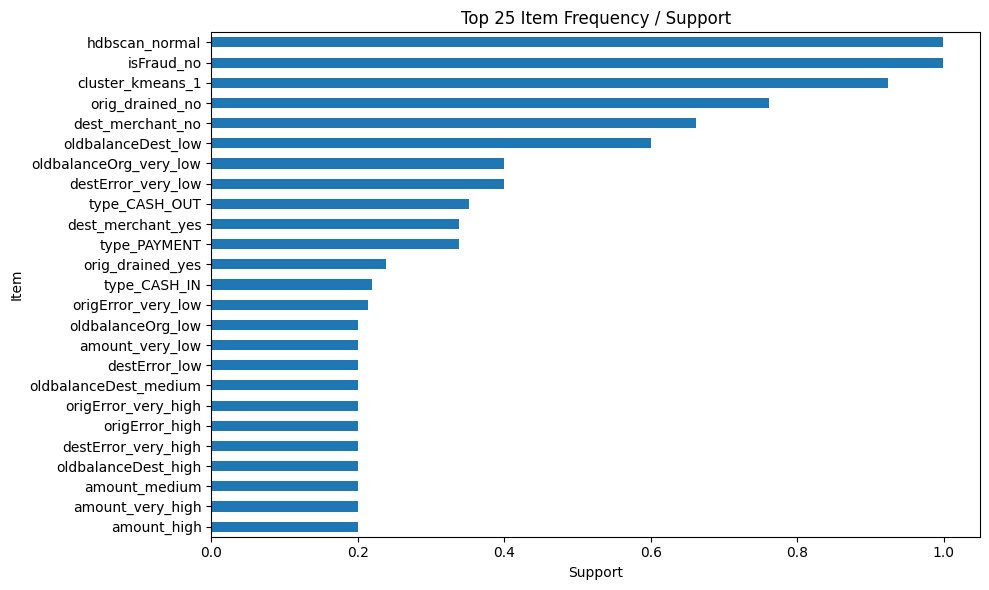

In [5]:
item_frequency = basket.mean().sort_values(ascending=False).to_frame("support")
display(item_frequency)

plt.figure(figsize=(10, 6))
item_frequency.head(25)["support"].sort_values().plot(kind="barh")
plt.title("Top 25 Item Frequency / Support")
plt.xlabel("Support")
plt.ylabel("Item")
plt.tight_layout()
plt.show()

In [6]:
MIN_SUPPORT = 0.005
MIN_CONFIDENCE = 0.50
MIN_LIFT = 1.20
MAX_LEN = 3

In [7]:
frequent_itemsets = apriori(
    basket,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=MAX_LEN,
    low_memory=True
)

frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
).reset_index(drop=True)

print("Frequent itemsets found:", len(frequent_itemsets))
display(frequent_itemsets.head(20))

Frequent itemsets found: 2936


,support,itemsets
0,0.999383,(hdbscan_normal)
1,0.998712,(isFraud_no)
2,0.998199,"(isFraud_no, hdbscan_normal)"
3,0.924157,(cluster_kmeans_1)
4,0.923918,"(cluster_kmeans_1, hdbscan_normal)"
5,0.923046,"(isFraud_no, cluster_kmeans_1)"
6,0.922808,"(isFraud_no, cluster_kmeans_1, hdbscan_normal)"
7,0.761013,(orig_drained_no)
8,0.760984,"(isFraud_no, orig_drained_no)"
9,0.760672,"(hdbscan_normal, orig_drained_no)"


In [8]:
if len(frequent_itemsets) == 0:
    raise ValueError("No frequent itemsets found. Coba turunkan MIN_SUPPORT.")

rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=MIN_LIFT
)

rules = rules[
    (rules["confidence"] >= MIN_CONFIDENCE) &
    (rules["lift"] >= MIN_LIFT)
].copy()

rules["antecedents_str"] = rules["antecedents"].apply(lambda x: ", ".join(sorted(list(x))))
rules["consequents_str"] = rules["consequents"].apply(lambda x: ", ".join(sorted(list(x))))
rules["antecedent_len"] = rules["antecedents"].apply(len)
rules["consequent_len"] = rules["consequents"].apply(len)

rules = rules.sort_values(
    by=["lift", "confidence", "support"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("Rules generated after filtering:", len(rules))
display(rules[[
    "antecedents_str",
    "consequents_str",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction"
]].head(20))

Rules generated after filtering: 2268


,antecedents_str,consequents_str,support,confidence,lift,leverage,conviction
0,type_DEBIT,"amount_very_low, destError_very_low",0.005420,0.832352,47.200336,0.005305,5.859685
1,type_DEBIT,"amount_very_low, dest_merchant_no",0.005905,0.906763,35.560732,0.005739,10.451858
2,cluster_kmeans_3,"oldbalanceOrg_very_high, type_CASH_IN",0.014070,0.998405,7.325951,0.012149,541.574498
3,cluster_kmeans_2,"oldbalanceOrg_very_high, type_CASH_IN",0.061243,0.995951,7.307946,0.052863,213.338557
4,cluster_kmeans_2,"destError_very_high, oldbalanceOrg_very_high",0.048769,0.793104,7.197255,0.041993,4.300726
5,cluster_kmeans_3,"destError_very_high, oldbalanceOrg_very_high",0.010707,0.759750,6.894579,0.009154,3.703664
6,"destError_very_low, origError_very_high",type_TRANSFER,0.046365,0.542498,6.477090,0.039206,2.002709
7,type_TRANSFER,"destError_very_low, origError_very_high",0.046365,0.553564,6.477090,0.039206,2.048523
8,"origError_very_high, orig_drained_yes",type_TRANSFER,0.023547,0.527691,6.300308,0.019810,1.939925
9,cluster_kmeans_3,"dest_merchant_no, oldbalanceOrg_very_high",0.014088,0.999688,6.094355,0.011776,2677.028506


In [9]:
def filter_meaningful_rules(rules):
    if len(rules) == 0:
        return rules.copy()

    filtered = rules.copy()

    trivial_consequents = [
        "isFraud_no",
        "hdbscan_normal",
        "orig_drained_no",
        "dest_merchant_no"
    ]

    for keyword in trivial_consequents:
        filtered = filtered[
            ~filtered["consequents_str"].str.contains(keyword, regex=False, na=False)
        ]

    important_mask = (
        filtered["consequents_str"].str.contains("isFraud_yes", regex=False, na=False) |
        filtered["consequents_str"].str.contains("hdbscan_outlier", regex=False, na=False) |
        filtered["consequents_str"].str.contains("cluster_kmeans", regex=False, na=False) |
        filtered["consequents_str"].str.contains("very_high", regex=False, na=False) |
        filtered["consequents_str"].str.contains("very_low", regex=False, na=False) |
        filtered["consequents_str"].str.contains("orig_drained_yes", regex=False, na=False) |
        filtered["consequents_str"].str.contains("dest_merchant_yes", regex=False, na=False)
    )

    filtered = filtered[important_mask].copy()

    return filtered.sort_values(
        by=["lift", "confidence", "support"],
        ascending=[False, False, False]
    ).reset_index(drop=True)


meaningful_rules = filter_meaningful_rules(rules)

print("Meaningful rules:", len(meaningful_rules))
display(meaningful_rules[[
    "antecedents_str",
    "consequents_str",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction"
]].head(20))

Meaningful rules: 857


,antecedents_str,consequents_str,support,confidence,lift,leverage,conviction
0,type_DEBIT,"amount_very_low, destError_very_low",0.005420,0.832352,47.200336,0.005305,5.859685
1,cluster_kmeans_3,"oldbalanceOrg_very_high, type_CASH_IN",0.014070,0.998405,7.325951,0.012149,541.574498
2,cluster_kmeans_2,"oldbalanceOrg_very_high, type_CASH_IN",0.061243,0.995951,7.307946,0.052863,213.338557
3,cluster_kmeans_2,"destError_very_high, oldbalanceOrg_very_high",0.048769,0.793104,7.197255,0.041993,4.300726
4,cluster_kmeans_3,"destError_very_high, oldbalanceOrg_very_high",0.010707,0.759750,6.894579,0.009154,3.703664
5,type_TRANSFER,"destError_very_low, origError_very_high",0.046365,0.553564,6.477090,0.039206,2.048523
6,cluster_kmeans_2,oldbalanceOrg_very_high,0.061492,1.000000,5.000007,0.049194,inf
7,"cluster_kmeans_2, dest_merchant_no",oldbalanceOrg_very_high,0.061437,1.000000,5.000007,0.049150,inf
8,"cluster_kmeans_2, hdbscan_normal",oldbalanceOrg_very_high,0.061367,1.000000,5.000007,0.049094,inf
9,"cluster_kmeans_2, orig_drained_no",oldbalanceOrg_very_high,0.061338,1.000000,5.000007,0.049071,inf


In [10]:
report_rules = meaningful_rules.copy()

report_rules = report_rules[
    ~report_rules["consequents_str"].str.contains(
        "isFraud_no|hdbscan_normal|orig_drained_no|dest_merchant_no",
        regex=True,
        na=False
    )
].copy()

report_rules = report_rules[
    (report_rules["confidence"] >= 0.30) &
    (report_rules["lift"] >= 1.20)
].copy()

report_rules = report_rules.sort_values(
    by=["lift", "confidence", "support"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("Report-worthy rules:", len(report_rules))

display(report_rules[[
    "antecedents_str",
    "consequents_str",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction"
]].head(30))

Report-worthy rules: 857


,antecedents_str,consequents_str,support,confidence,lift,leverage,conviction
0,type_DEBIT,"amount_very_low, destError_very_low",0.005420,0.832352,47.200336,0.005305,5.859685
1,cluster_kmeans_3,"oldbalanceOrg_very_high, type_CASH_IN",0.014070,0.998405,7.325951,0.012149,541.574498
2,cluster_kmeans_2,"oldbalanceOrg_very_high, type_CASH_IN",0.061243,0.995951,7.307946,0.052863,213.338557
3,cluster_kmeans_2,"destError_very_high, oldbalanceOrg_very_high",0.048769,0.793104,7.197255,0.041993,4.300726
4,cluster_kmeans_3,"destError_very_high, oldbalanceOrg_very_high",0.010707,0.759750,6.894579,0.009154,3.703664
5,type_TRANSFER,"destError_very_low, origError_very_high",0.046365,0.553564,6.477090,0.039206,2.048523
6,cluster_kmeans_2,oldbalanceOrg_very_high,0.061492,1.000000,5.000007,0.049194,inf
7,"cluster_kmeans_2, dest_merchant_no",oldbalanceOrg_very_high,0.061437,1.000000,5.000007,0.049150,inf
8,"cluster_kmeans_2, hdbscan_normal",oldbalanceOrg_very_high,0.061367,1.000000,5.000007,0.049094,inf
9,"cluster_kmeans_2, orig_drained_no",oldbalanceOrg_very_high,0.061338,1.000000,5.000007,0.049071,inf


In [11]:
important_items = [
    "isFraud_yes",
    "isFraud_no",
    "hdbscan_outlier",
    "hdbscan_normal",
    "orig_drained_yes",
    "orig_drained_no",
    "dest_merchant_yes",
    "dest_merchant_no"
]

for item in important_items:
    if item in basket.columns:
        print(f"{item}: {basket[item].mean():.6f} ({basket[item].mean() * 100:.4f}%)")

isFraud_yes: 0.001288 (0.1288%)
isFraud_no: 0.998712 (99.8712%)
hdbscan_outlier: 0.000617 (0.0617%)
hdbscan_normal: 0.999383 (99.9383%)
orig_drained_yes: 0.238987 (23.8987%)
orig_drained_no: 0.761013 (76.1013%)
dest_merchant_yes: 0.338147 (33.8147%)
dest_merchant_no: 0.661853 (66.1853%)


In [12]:
fraud_itemsets = apriori(
    basket,
    min_support=0.0001,
    use_colnames=True,
    max_len=3,
    low_memory=True
)

fraud_rules = association_rules(
    fraud_itemsets,
    metric="lift",
    min_threshold=1.2
)

fraud_rules["antecedents_str"] = fraud_rules["antecedents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

fraud_rules["consequents_str"] = fraud_rules["consequents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

fraud_rules = fraud_rules[
    fraud_rules["consequents_str"].str.contains("isFraud_yes", regex=False, na=False)
].copy()

fraud_rules = fraud_rules[
    ~fraud_rules["antecedents_str"].str.contains(
        "isFraud_no",
        regex=True,
        na=False
    )
].copy()

fraud_rules = fraud_rules.sort_values(
    by=["lift", "confidence", "support"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("Fraud rules:", len(fraud_rules))

display(fraud_rules[[
    "antecedents_str",
    "consequents_str",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction"
]].head(20))

Fraud rules: 266


,antecedents_str,consequents_str,support,confidence,lift,leverage,conviction
0,"origError_very_low, orig_drained_yes",isFraud_yes,0.001259,1.000000,776.211297,0.001257,inf
1,"cluster_kmeans_2, orig_drained_yes",isFraud_yes,0.000154,1.000000,776.211297,0.000154,inf
2,"hdbscan_outlier, origError_very_low",isFraud_yes,0.000103,0.904432,702.030439,0.000102,10.450288
3,"cluster_kmeans_2, origError_very_low",isFraud_yes,0.000161,0.649746,504.340335,0.000161,2.851394
4,"hdbscan_outlier, oldbalanceOrg_very_high",isFraud_yes,0.000104,0.485380,376.757530,0.000104,1.940678
5,hdbscan_outlier,"amount_very_high, isFraud_yes",0.000104,0.169258,209.885604,0.000104,1.202773
6,hdbscan_outlier,"isFraud_yes, oldbalanceOrg_very_high",0.000104,0.169258,197.022143,0.000104,1.202709
7,"amount_very_high, hdbscan_outlier",isFraud_yes,0.000104,0.204308,158.585939,0.000104,1.255148
8,"amount_very_high, origError_very_low",isFraud_yes,0.000802,0.194208,150.746166,0.000797,1.239416
9,"dest_merchant_no, hdbscan_outlier",isFraud_yes,0.000104,0.170169,132.087212,0.000104,1.203512


In [13]:
selected_parts = []

if "fraud_rules" in globals() and len(fraud_rules) > 0:
    selected_parts.append(fraud_rules.head(4))

outlier_rules = report_rules[
    report_rules["consequents_str"].str.contains("hdbscan_outlier", regex=False, na=False)
].copy()

if len(outlier_rules) > 0:
    selected_parts.append(outlier_rules.head(2))

cluster_rules = report_rules[
    report_rules["consequents_str"].str.contains("cluster_kmeans", regex=False, na=False)
].copy()

if len(cluster_rules) > 0:
    selected_parts.append(cluster_rules.head(2))

general_rules = report_rules[
    ~report_rules["consequents_str"].str.contains(
        "isFraud_yes|hdbscan_outlier|cluster_kmeans",
        regex=True,
        na=False
    )
].copy()

if len(general_rules) > 0:
    selected_parts.append(general_rules.head(5))

top_10_final = pd.concat(selected_parts, ignore_index=True)

top_10_final = top_10_final.drop_duplicates(
    subset=["antecedents_str", "consequents_str"]
)

if len(top_10_final) < 10:
    filler = report_rules[
        ~report_rules.set_index(["antecedents_str", "consequents_str"]).index.isin(
            top_10_final.set_index(["antecedents_str", "consequents_str"]).index
        )
    ].copy()

    top_10_final = pd.concat(
        [top_10_final, filler.head(10 - len(top_10_final))],
        ignore_index=True
    )

top_10_final = top_10_final.head(10).copy()

display(top_10_final[[
    "antecedents_str",
    "consequents_str",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction"
]])

,antecedents_str,consequents_str,support,confidence,lift,leverage,conviction
0,"origError_very_low, orig_drained_yes",isFraud_yes,0.001259,1.000000,776.211297,0.001257,inf
1,"cluster_kmeans_2, orig_drained_yes",isFraud_yes,0.000154,1.000000,776.211297,0.000154,inf
2,"hdbscan_outlier, origError_very_low",isFraud_yes,0.000103,0.904432,702.030439,0.000102,10.450288
3,"cluster_kmeans_2, origError_very_low",isFraud_yes,0.000161,0.649746,504.340335,0.000161,2.851394
4,type_DEBIT,"amount_very_low, cluster_kmeans_1",0.005904,0.906618,4.597684,0.004620,8.597058
5,destError_low,"amount_very_low, cluster_kmeans_1",0.176434,0.882169,4.473699,0.136996,6.813256
6,type_DEBIT,"amount_very_low, destError_very_low",0.005420,0.832352,47.200336,0.005305,5.859685
7,cluster_kmeans_3,"oldbalanceOrg_very_high, type_CASH_IN",0.014070,0.998405,7.325951,0.012149,541.574498
8,cluster_kmeans_2,"oldbalanceOrg_very_high, type_CASH_IN",0.061243,0.995951,7.307946,0.052863,213.338557
9,cluster_kmeans_2,"destError_very_high, oldbalanceOrg_very_high",0.048769,0.793104,7.197255,0.041993,4.300726


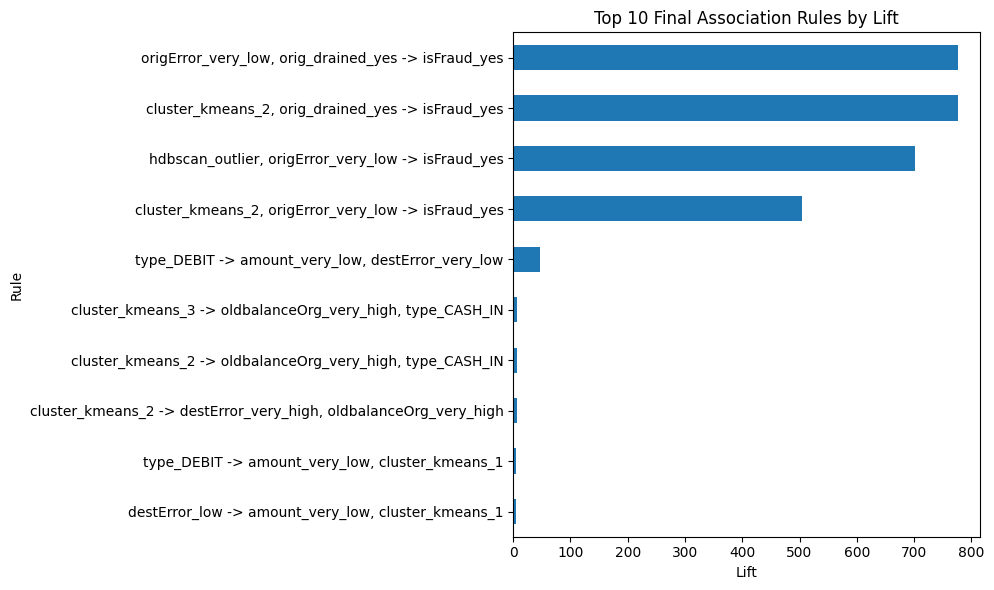

In [14]:
if len(top_10_final) > 0:
    plot_df = top_10_final.copy()
    plot_df["rule"] = plot_df["antecedents_str"] + " -> " + plot_df["consequents_str"]

    plt.figure(figsize=(10, 6))
    plot_df.set_index("rule")["lift"].sort_values().plot(kind="barh")
    plt.title("Top 10 Final Association Rules by Lift")
    plt.xlabel("Lift")
    plt.ylabel("Rule")
    plt.tight_layout()
    plt.show()
else:
    print("No top rules available to plot.")

In [15]:
top_10_final = top_10_final[
    ~top_10_final["antecedents_str"].str.contains(
        "isFraud_no|hdbscan_normal|orig_drained_no",
        regex=True,
        na=False
    )
].copy()

if len(top_10_final) < 10:
    existing_pairs = set(
        zip(top_10_final["antecedents_str"], top_10_final["consequents_str"])
    )

    filler = report_rules[
        ~report_rules["antecedents_str"].str.contains(
            "isFraud_no|hdbscan_normal|orig_drained_no",
            regex=True,
            na=False
        )
    ].copy()

    filler = filler[
        ~filler.apply(
            lambda row: (row["antecedents_str"], row["consequents_str"]) in existing_pairs,
            axis=1
        )
    ]

    top_10_final = pd.concat(
        [top_10_final, filler.head(10 - len(top_10_final))],
        ignore_index=True
    )

top_10_final = top_10_final.head(10).copy()

display(top_10_final[[
    "antecedents_str",
    "consequents_str",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction"
]])

,antecedents_str,consequents_str,support,confidence,lift,leverage,conviction
0,"origError_very_low, orig_drained_yes",isFraud_yes,0.001259,1.000000,776.211297,0.001257,inf
1,"cluster_kmeans_2, orig_drained_yes",isFraud_yes,0.000154,1.000000,776.211297,0.000154,inf
2,"hdbscan_outlier, origError_very_low",isFraud_yes,0.000103,0.904432,702.030439,0.000102,10.450288
3,"cluster_kmeans_2, origError_very_low",isFraud_yes,0.000161,0.649746,504.340335,0.000161,2.851394
4,type_DEBIT,"amount_very_low, cluster_kmeans_1",0.005904,0.906618,4.597684,0.004620,8.597058
5,destError_low,"amount_very_low, cluster_kmeans_1",0.176434,0.882169,4.473699,0.136996,6.813256
6,type_DEBIT,"amount_very_low, destError_very_low",0.005420,0.832352,47.200336,0.005305,5.859685
7,cluster_kmeans_3,"oldbalanceOrg_very_high, type_CASH_IN",0.014070,0.998405,7.325951,0.012149,541.574498
8,cluster_kmeans_2,"oldbalanceOrg_very_high, type_CASH_IN",0.061243,0.995951,7.307946,0.052863,213.338557
9,cluster_kmeans_2,"destError_very_high, oldbalanceOrg_very_high",0.048769,0.793104,7.197255,0.041993,4.300726


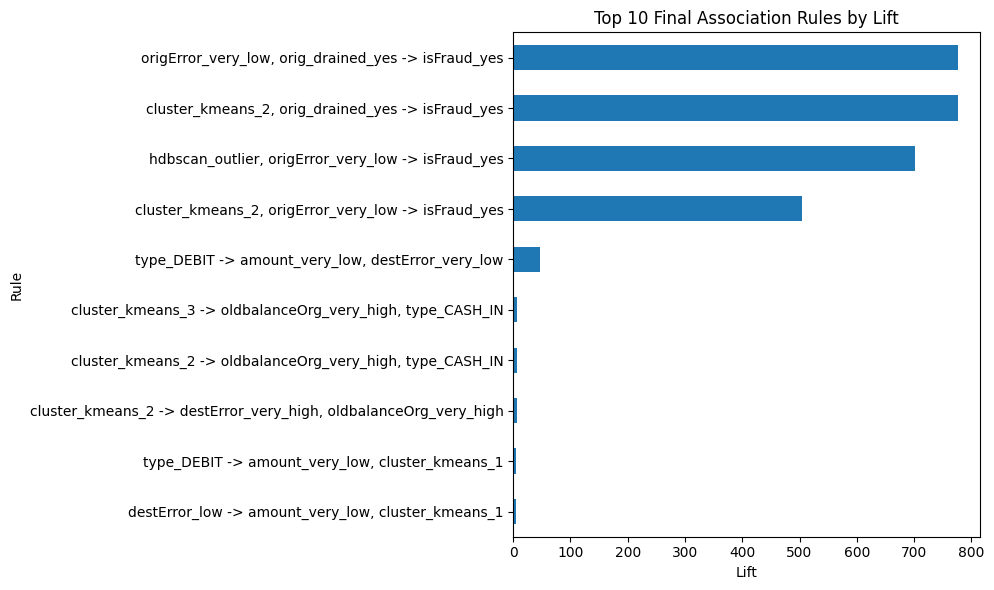

In [16]:
if len(top_10_final) > 0:
    plot_df = top_10_final.copy()
    plot_df["rule"] = plot_df["antecedents_str"] + " -> " + plot_df["consequents_str"]

    plt.figure(figsize=(10, 6))
    plot_df.set_index("rule")["lift"].sort_values().plot(kind="barh")
    plt.title("Top 10 Final Association Rules by Lift")
    plt.xlabel("Lift")
    plt.ylabel("Rule")
    plt.tight_layout()
    plt.show()
else:
    print("No top rules available to plot.")